In [1]:
"""
COMPLETE FALL DETECTION SYSTEM - FROM SCRATCH
Deep Learning Approach (CNN, LSTM, CNN-LSTM)

Instructions:
1. Download SisFall dataset from: http://sistemic.udea.edu.co/~publico/Repository/SisFall_dataset.zip
2. Extract it to get 'SisFall_dataset' folder
3. Place this notebook in the same folder as 'SisFall_dataset'
4. Run all cells in order
"""

# ============================================================================
# CELL 1: Install and Import Libraries
# ============================================================================

# Run this first if packages are missing:
# !pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("✓ TensorFlow version:", tf.__version__)
print("✓ GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)
print("✓ All libraries imported successfully!")




✓ TensorFlow version: 2.17.0
✓ GPU available: False
✓ All libraries imported successfully!


In [2]:
# ============================================================================
# DIAGNOSTIC: Check file format
# ============================================================================

import os

# Path to one file
test_file = r'D:\Downloads\Sisfall\SisFall_dataset\SA01\D01_SA01_R01.txt'

print("="*70)
print("FILE DIAGNOSTIC")
print("="*70)

if os.path.exists(test_file):
    print(f"✓ File exists: {test_file}")
    
    # Read first 10 lines
    with open(test_file, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()[:10]
    
    print(f"\n📄 First 10 lines of the file:")
    print("-"*70)
    for i, line in enumerate(lines, 1):
        print(f"Line {i}: {repr(line)}")
    
    # Check delimiters
    print("\n🔍 Delimiter analysis:")
    sample_line = lines[0] if lines else ""
    print(f"  Contains ';' : {';' in sample_line}")
    print(f"  Contains ',' : {',' in sample_line}")
    tab_char = '\t'
    print(f"  Contains tab : {tab_char in sample_line}")
    print(f"  Contains space : {' ' in sample_line}")
    print(f"  Line length: {len(sample_line)}")
    
else:
    print(f"❌ File not found: {test_file}")
    print("\n🔍 Checking parent directory...")
    parent_dir = r'D:\Downloads\Sisfall\SisFall_dataset\SA01'
    if os.path.exists(parent_dir):
        files = os.listdir(parent_dir)[:5]
        print(f"Files found in SA01: {files}")
    else:
        print(f"❌ Directory not found: {parent_dir}")

FILE DIAGNOSTIC
✓ File exists: D:\Downloads\Sisfall\SisFall_dataset\SA01\D01_SA01_R01.txt

📄 First 10 lines of the file:
----------------------------------------------------------------------
Line 1: '  17,-179, -99, -18,-504,-352,  76,-697,-279;\n'
Line 2: '  15,-174, -90, -53,-568,-306,  48,-675,-254;\n'
Line 3: '   1,-176, -81, -84,-613,-271,  -2,-668,-221;\n'
Line 4: ' -10,-180, -77,-104,-647,-227, -34,-697,-175;\n'
Line 5: ' -21,-191, -63,-128,-675,-191, -74,-741,-133;\n'
Line 6: ' -37,-225, -59,-146,-700,-159,-110,-840,-103;\n'
Line 7: ' -36,-243, -46,-166,-722,-131,-147,-948, -75;\n'
Line 8: ' -44,-271, -38,-190,-738,-107,-171,-1073, -38;\n'
Line 9: ' -51,-312, -33,-210,-752, -90,-200,-1191,   3;\n'
Line 10: ' -55,-339, -19,-214,-764, -72,-212,-1298,  52;\n'

🔍 Delimiter analysis:
  Contains ';' : True
  Contains ',' : True
  Contains tab : False
  Contains space : True
  Line length: 46


In [3]:
# ============================================================================
# CELL 2: Load SisFall Dataset (DEBUG VERSION)
# ============================================================================

def load_sisfall_dataset(dataset_path='SisFall_dataset', max_subjects=None, verbose=True):
    """
    Load all data from SisFall dataset
    """
    
    if verbose:
        print("="*70)
        print("LOADING SISFALL DATASET")
        print("="*70)
    
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(
            f"Dataset folder '{dataset_path}' not found!"
        )
    
    # Get all subject folders
    subjects = sorted([
        f for f in os.listdir(dataset_path) 
        if os.path.isdir(os.path.join(dataset_path, f)) 
        and (f.startswith('SA') or f.startswith('SE'))
    ])
    
    if max_subjects:
        subjects = subjects[:max_subjects]
    
    if verbose:
        print(f"📂 Found {len(subjects)} subject folders")
        print(f"⏳ Loading data...")
    
    all_data = []
    loaded_count = 0
    error_count = 0
    debug_first_file = True
    
    for subject_idx, subject in enumerate(subjects):
        subject_path = os.path.join(dataset_path, subject)
        files = sorted([f for f in os.listdir(subject_path) if f.endswith('.txt')])
        
        for file in files:
            filepath = os.path.join(subject_path, file)
            
            try:
                # Read file
                with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                    lines = f.readlines()
                
                # Debug first file
                if debug_first_file and verbose:
                    print(f"\n🔍 Debugging first file: {file}")
                    print(f"  Total lines in file: {len(lines)}")
                    print(f"  First line: {repr(lines[0][:100])}")
                    debug_first_file = False
                
                # Parse each line
                data_rows = []
                for line_idx, line in enumerate(lines):
                    # Remove whitespace and semicolon at the end
                    line = line.strip().rstrip(';')
                    
                    if not line:
                        continue
                    
                    # Split by comma
                    values = line.split(',')
                    
                    # Debug first line parsing
                    if line_idx == 0 and loaded_count == 0 and verbose:
                        print(f"  After split: {values}")
                        print(f"  Number of values: {len(values)}")
                    
                    # Convert to float
                    try:
                        row = [float(v.strip()) for v in values]
                        
                        # Only keep rows with exactly 6 or 9 values (some datasets have 9)
                        if len(row) in [6, 9]:
                            data_rows.append(row[:6])  # Keep first 6
                    except ValueError as e:
                        if line_idx == 0 and loaded_count == 0 and verbose:
                            print(f"  ⚠ Conversion error: {e}")
                        continue
                
                # Debug data rows
                if loaded_count == 0 and verbose:
                    print(f"  Valid data rows found: {len(data_rows)}")
                    if len(data_rows) > 0:
                        print(f"  First row shape: {np.array(data_rows[0]).shape}")
                
                # Convert to numpy array (lowered threshold to 5)
                if len(data_rows) >= 5:
                    data = np.array(data_rows, dtype=np.float32)
                    
                    # Parse filename
                    activity_code = file.split('_')[0]
                    is_fall = 1 if activity_code.startswith('F') else 0
                    
                    all_data.append({
                        'data': data,
                        'activity': activity_code,
                        'subject': subject,
                        'is_fall': is_fall
                    })
                    
                    loaded_count += 1
                    
                    if loaded_count == 1 and verbose:
                        print(f"  ✅ Successfully loaded first file!")
                        print(f"     Shape: {data.shape}")
                else:
                    error_count += 1
                    if error_count <= 3 and verbose:
                        print(f"  ⚠ Skipping {file}: Only {len(data_rows)} valid rows")
                
            except Exception as e:
                error_count += 1
                if error_count <= 3 and verbose:
                    print(f"  ⚠ Error loading {file}: {str(e)}")
        
        if verbose and (subject_idx + 1) % 5 == 0:
            print(f"\n  ✓ Processed {subject_idx + 1}/{len(subjects)} subjects... (Loaded: {loaded_count}, Errors: {error_count})")
    
    if verbose:
        if loaded_count > 0:
            falls = sum(d['is_fall'] for d in all_data)
            activities = loaded_count - falls
            print(f"\n✅ Loading complete!")
            print(f"  ✓ Total recordings: {loaded_count}")
            print(f"  ✓ Falls: {falls} ({100*falls/loaded_count:.1f}%)")
            print(f"  ✓ Activities: {activities} ({100*activities/loaded_count:.1f}%)")
        else:
            print(f"\n❌ Loading FAILED!")
            print(f"  ✗ Total errors: {error_count}")
    
    if loaded_count == 0:
        raise ValueError("No data files were successfully loaded.")
    
    return all_data


# Load the data
print("\n🚀 Starting data loading...\n")
all_data = load_sisfall_dataset(
    dataset_path=r'D:\Downloads\Sisfall\SisFall_dataset',
    max_subjects=10
)


🚀 Starting data loading...

LOADING SISFALL DATASET
📂 Found 10 subject folders
⏳ Loading data...

🔍 Debugging first file: D01_SA01_R01.txt
  Total lines in file: 19999
  First line: '  17,-179, -99, -18,-504,-352,  76,-697,-279;\n'
  After split: ['17', '-179', ' -99', ' -18', '-504', '-352', '  76', '-697', '-279']
  Number of values: 9
  Valid data rows found: 19999
  First row shape: (6,)
  ✅ Successfully loaded first file!
     Shape: (19999, 6)

  ✓ Processed 5/10 subjects... (Loaded: 770, Errors: 0)

  ✓ Processed 10/10 subjects... (Loaded: 1540, Errors: 0)

✅ Loading complete!
  ✓ Total recordings: 1540
  ✓ Falls: 750 (48.7%)
  ✓ Activities: 790 (51.3%)


In [4]:
# ============================================================================
# CELL 3: Create Sliding Windows
# ============================================================================

def create_sliding_windows(all_data, window_size=200, step_size=100, verbose=True):
    """
    Create sliding windows from time series data
    
    Parameters:
    -----------
    all_data : list
        List of recording dictionaries
    window_size : int
        Number of samples per window (200 = 1 second at 200Hz)
    step_size : int
        Step between windows (100 = 50% overlap)
    
    Returns:
    --------
    X : numpy array of shape (n_windows, window_size, 6)
    y : numpy array of shape (n_windows,) with labels (0 or 1)
    """
    
    if verbose:
        print("\n" + "="*70)
        print("CREATING SLIDING WINDOWS")
        print("="*70)
        print(f"⚙️ Window size: {window_size} samples ({window_size/200:.2f} seconds)")
        print(f"⚙️ Step size: {step_size} samples ({100*(1-step_size/window_size):.0f}% overlap)")
    
    X_windows = []
    y_labels = []
    
    for recording in all_data:
        data = recording['data']  # Shape: (n_samples, 6)
        label = recording['is_fall']  # 0 or 1
        
        # Create sliding windows
        for start in range(0, len(data) - window_size + 1, step_size):
            window = data[start:start + window_size]
            
            if len(window) == window_size:
                X_windows.append(window)
                y_labels.append(label)
    
    # Convert to numpy arrays
    X = np.array(X_windows, dtype=np.float32)
    y = np.array(y_labels, dtype=np.int32)
    
    if verbose:
        print(f"\n✅ Windows created!")
        print(f"  ✓ Total windows: {len(X)}")
        print(f"  ✓ X shape: {X.shape} (samples, time_steps, features)")
        print(f"  ✓ y shape: {y.shape}")
        print(f"  ✓ Falls: {np.sum(y==1)} ({100*np.sum(y==1)/len(y):.1f}%)")
        print(f"  ✓ Non-falls: {np.sum(y==0)} ({100*np.sum(y==0)/len(y):.1f}%)")
    
    return X, y


# Create windows
X, y = create_sliding_windows(
    all_data, 
    window_size=200,  # 1 second at 200Hz
    step_size=100     # 50% overlap
)


CREATING SLIDING WINDOWS
⚙️ Window size: 200 samples (1.00 seconds)
⚙️ Step size: 100 samples (50% overlap)

✅ Windows created!
  ✓ Total windows: 50758
  ✓ X shape: (50758, 200, 6) (samples, time_steps, features)
  ✓ y shape: (50758,)
  ✓ Falls: 21712 (42.8%)
  ✓ Non-falls: 29046 (57.2%)


In [5]:
# ============================================================================
# CELL 4: Train-Test Split
# ============================================================================

def split_data(X, y, test_size=0.2, random_state=42, verbose=True):
    """
    Split data into training and test sets
    """
    
    if verbose:
        print("\n" + "="*70)
        print("SPLITTING DATA")
        print("="*70)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y  # Keep same class distribution
    )
    
    if verbose:
        print(f"✓ Training set: {len(X_train)} samples")
        print(f"✓ Test set: {len(X_test)} samples")
        print(f"✓ Split ratio: {int((1-test_size)*100)}/{int(test_size*100)}")
        
        print(f"\n✓ Training set distribution:")
        print(f"  - Non-Fall: {np.sum(y_train==0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")
        print(f"  - Fall: {np.sum(y_train==1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")
        
        print(f"\n✓ Test set distribution:")
        print(f"  - Non-Fall: {np.sum(y_test==0)} ({100*np.sum(y_test==0)/len(y_test):.1f}%)")
        print(f"  - Fall: {np.sum(y_test==1)} ({100*np.sum(y_test==1)/len(y_test):.1f}%)")
    
    return X_train, X_test, y_train, y_test


# Split the data
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)

# Convert labels to categorical for neural networks
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

print("\n✅ Data preparation complete! Ready for training.")



SPLITTING DATA
✓ Training set: 40606 samples
✓ Test set: 10152 samples
✓ Split ratio: 80/20

✓ Training set distribution:
  - Non-Fall: 23237 (57.2%)
  - Fall: 17369 (42.8%)

✓ Test set distribution:
  - Non-Fall: 5809 (57.2%)
  - Fall: 4343 (42.8%)

✅ Data preparation complete! Ready for training.


In [6]:
# ============================================================================
# CELL 11: Build CNN-LSTM Hybrid Model (BEST)
# ============================================================================

def build_cnn_lstm_model(input_shape):
    """
    Build hybrid CNN-LSTM model (usually best for time series)
    """
    model = Sequential([
        # CNN Layers for feature extraction
        Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(64, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # LSTM Layers for temporal patterns
        LSTM(100, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(100),
        BatchNormalization(),
        Dropout(0.4),
        
        # Dense Layers
        Dense(100, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(50, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    
    return model


print("\n" + "="*70)
print("MODEL 3: CNN-LSTM HYBRID (RECOMMENDED)")
print("="*70)

# Build model
cnn_lstm_model = build_cnn_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))

# Compile
cnn_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📋 CNN-LSTM Model Architecture:")
cnn_lstm_model.summary()




MODEL 3: CNN-LSTM HYBRID (RECOMMENDED)

📋 CNN-LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 196, 64)             │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 196, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 192, 64)             │          20,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 192, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 96, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 96, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 94, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 94, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 47, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 47, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 47, 100)             │          91,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 47, 100)             │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 47, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100)                 │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 236,708 (924.64 KB)

 Trainable params: 235,596 (920.30 KB)

 Non-trainable params: 1,112 (4.34 KB)

In [7]:
# ============================================================================
# CELL 12: Train CNN-LSTM Model
# ============================================================================

print("\n⏳ Training CNN-LSTM model...")


# Calculate class weights
class_weight = {
    0: len(y_train) / (2 * np.sum(y_train == 0)),
    1: len(y_train) / (2 * np.sum(y_train == 1))
}

print(f"Class weights: {class_weight}")


# Callbacks
cnn_lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-7),
    ModelCheckpoint('best_cnn_lstm_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)  # Changed
]

# Train
cnn_lstm_history = cnn_lstm_model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=cnn_lstm_callbacks,
    verbose=1
)

print("\n✅ CNN-LSTM training complete!")

# Evaluate
cnn_lstm_results = evaluate_model(cnn_lstm_model, X_test, y_test, y_test_cat, "CNN-LSTM")
plot_training_history(cnn_lstm_history, 'CNN-LSTM')




⏳ Training CNN-LSTM model...
Class weights: {0: 0.8737358523045143, 1: 1.1689216420058726}
Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.6953 - loss: 0.6760
Epoch 1: val_accuracy improved from -inf to 0.78093, saving model to best_cnn_lstm_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 147s 211ms/step - accuracy: 0.6954 - loss: 0.6759 - val_accuracy: 0.7809 - val_loss: 0.4668 - learning_rate: 0.0010
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7744 - loss: 0.4664
Epoch 2: val_accuracy improved from 0.78093 to 0.79827, saving model to best_cnn_lstm_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 121s 191ms/step - accuracy: 0.7744 - loss: 0.4664 - val_accuracy: 0.7983 - val_loss: 0.4391 - learning_rate: 0.0010
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7921 - loss: 0.4422
Epoch 3: val_accuracy improved from 0.79827 to 0.81048, saving model to best_cnn_lstm_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 126s 198ms/step - accuracy: 0.7921

NameError: name 'evaluate_model' is not defined

🔍 Evaluating CNN-LSTM Model...

CNN-LSTM - EVALUATION RESULTS

📊 Metrics:
  Accuracy:  0.9233
  Precision: 0.8894
  Recall:    0.9371 ← (Most important for fall detection)
  F1-Score:  0.9127

📋 Classification Report:
              precision    recall  f1-score   support

    Non-Fall       0.95      0.91      0.93      5809
        Fall       0.89      0.94      0.91      4343

    accuracy                           0.92     10152
   macro avg       0.92      0.93      0.92     10152
weighted avg       0.92      0.92      0.92     10152



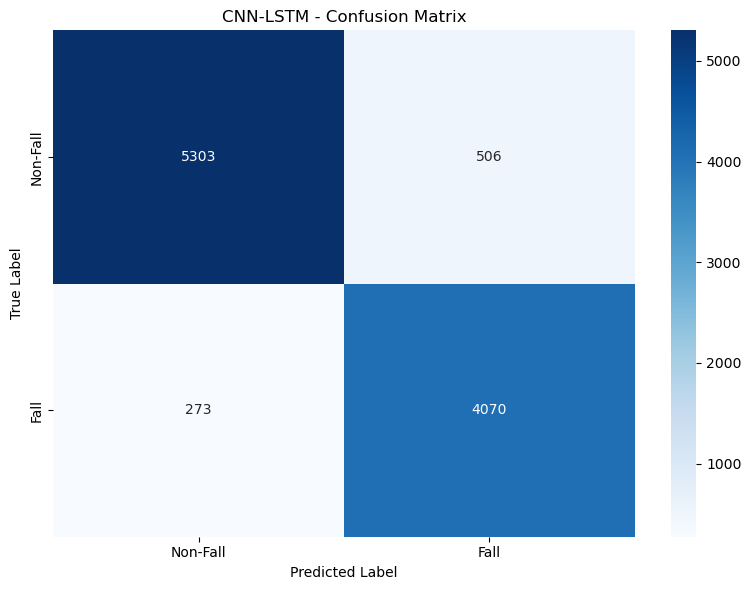

In [8]:
# ============================================================================
# Evaluate CNN-LSTM Model (Run this after training)
# ============================================================================

# Make sure evaluate_model function exists (from CELL 7)
def evaluate_model(model, X_test, y_test, y_test_cat, model_name):
    """
    Evaluate model and print metrics
    """
    print("\n" + "="*70)
    print(f"{model_name} - EVALUATION RESULTS")
    print("="*70)
    
    # Predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n📊 Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f} ← (Most important for fall detection)")
    print(f"  F1-Score:  {f1:.4f}")
    
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Fall', 'Fall']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Fall', 'Fall'],
                yticklabels=['Non-Fall', 'Fall'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred
    }

# Evaluate CNN-LSTM
print("🔍 Evaluating CNN-LSTM Model...")
cnn_lstm_results = evaluate_model(cnn_lstm_model, X_test, y_test, y_test_cat, "CNN-LSTM")


📈 Plotting training history...


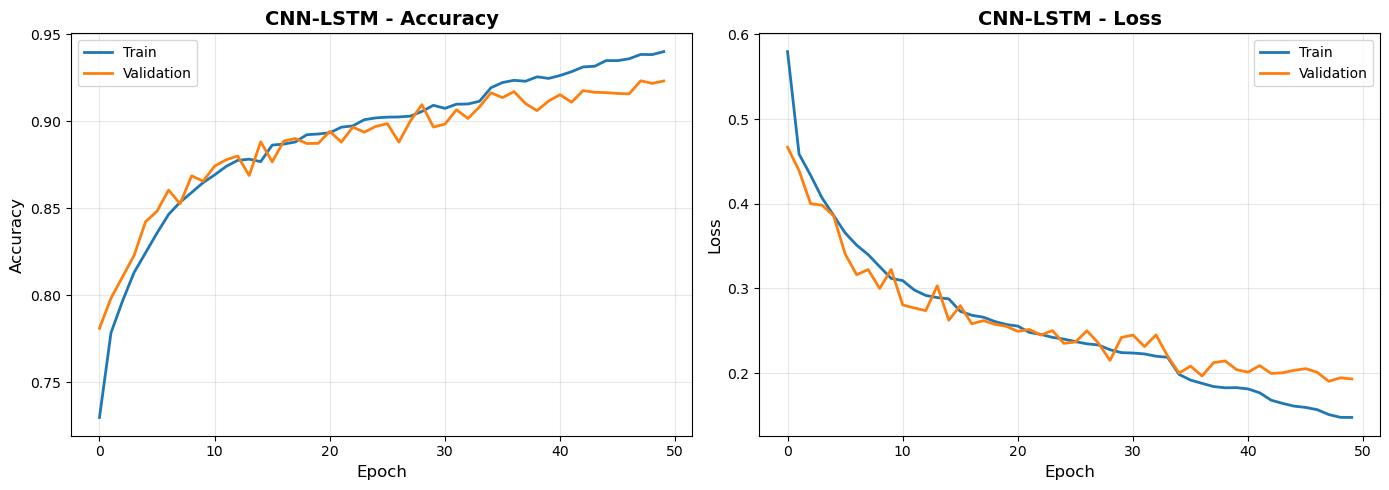

In [9]:
# Plot training history
def plot_training_history(history, model_name):
    """
    Plot training and validation accuracy/loss
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n📈 Plotting training history...")
plot_training_history(cnn_lstm_history, 'CNN-LSTM')

In [10]:
# Quick evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred_proba = cnn_lstm_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("="*70)
print("CNN-LSTM MODEL - QUICK RESULTS")
print("="*70)
print(f"\n✅ Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision: {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n[[True Negatives, False Positives],")
print(" [False Negatives, True Positives]]")

CNN-LSTM MODEL - QUICK RESULTS

✅ Accuracy:  0.9233
✅ Precision: 0.8894
✅ Recall:    0.9371
✅ F1-Score:  0.9127

📊 Confusion Matrix:
[[5303  506]
 [ 273 4070]]

[[True Negatives, False Positives],
 [False Negatives, True Positives]]


In [11]:
# ============================================================================
# Save and Verify CNN-LSTM Model Only
# ============================================================================

import os
from tensorflow import keras

print("="*70)
print("SAVING CNN-LSTM MODEL")
print("="*70)

# Save the model
model_filename = 'best_cnn_lstm_model.keras'
cnn_lstm_model.save(model_filename)

# Verify
if os.path.exists(model_filename):
    file_size_mb = os.path.getsize(model_filename) / (1024 * 1024)
    print(f"\n✅ Model saved successfully!")
    print(f"  📁 Filename: {model_filename}")
    print(f"  📊 Size: {file_size_mb:.2f} MB")
    print(f"  📂 Location: {os.path.abspath(model_filename)}")
    
    # Test loading
    print("\n🔍 Testing model loading...")
    try:
        loaded_model = keras.models.load_model(model_filename)
        
        # Test prediction
        test_sample = X_test[0:1]
        prediction = loaded_model.predict(test_sample, verbose=0)
        predicted_class = np.argmax(prediction)
        confidence = prediction[0][predicted_class]
        
        print(f"  ✅ Model loaded successfully!")
        print(f"  ✅ Test prediction works!")
        print(f"     Predicted: {'FALL' if predicted_class == 1 else 'NON-FALL'}")
        print(f"     Confidence: {confidence:.4f}")
        
    except Exception as e:
        print(f"  ❌ Error loading model: {str(e)}")
else:
    print(f"\n❌ Model file not found!")

print("\n" + "="*70)

SAVING CNN-LSTM MODEL

✅ Model saved successfully!
  📁 Filename: best_cnn_lstm_model.keras
  📊 Size: 2.80 MB
  📂 Location: C:\Users\User\best_cnn_lstm_model.keras

🔍 Testing model loading...
  ✅ Model loaded successfully!
  ✅ Test prediction works!
     Predicted: NON-FALL
     Confidence: 1.0000



In [13]:
import tensorflow as tf

# 1. Load the model
model = tf.keras.models.load_model("best_cnn_lstm_model.keras")

# 2. Create converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Fix for LSTM TensorListReserve error
converter.experimental_enable_resource_variables = True
converter._experimental_lower_tensor_list_ops = False

# 4. Allow SELECT_TF_OPS (required for LSTM)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS
]

# 5. Convert
tflite_model = converter.convert()

# 6. Save
with open("best_cnn_lstm_model.tflite", "wb") as f:
    f.write(tflite_model)

print("DONE — TFLite model saved successfully!")


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp67uzc5xz\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp67uzc5xz\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp67uzc5xz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2332496139408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496139984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496140560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496140752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496139792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496140176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496141520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496142672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496143056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332496141136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  233249614190